## Description 

This notebook illustrates different *representations* of multivariate time-series data. Different data representations encode different information.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.mplot3d import Axes3D

In [2]:
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'axes.labelsize': 20,  
    'xtick.labelsize': 18, 
    'ytick.labelsize': 18, 
    'axes.titlesize': 24 
})

## Data Representation 1: TIME-SERIES 

Multivariate time-series data is most commonly visualized as raw time-series trajectories for each variable. 

In [3]:
time_series = np.array([[0,0,0,1,1,1,1,0,0,0],
                       [1,2,2,3,3,3,3,2,2,1],
                       [3,4,5,6,7,7,6,5,4,3],
                       [0,1,2,4,5,5,4,2,1,0],
                       [3,4,6,8,10,10,8,6,4,3],
                       [1,2,4,6,8,8,6,4,2,1],
                       [1,2,3,5,6,6,5,3,2,1],
                       [0,1,2,3,4,4,3,2,1,0],
                       [0,1,1,2,2,2,2,1,1,0],
                       [5,6,7,8,9,9,8,7,6,5]])

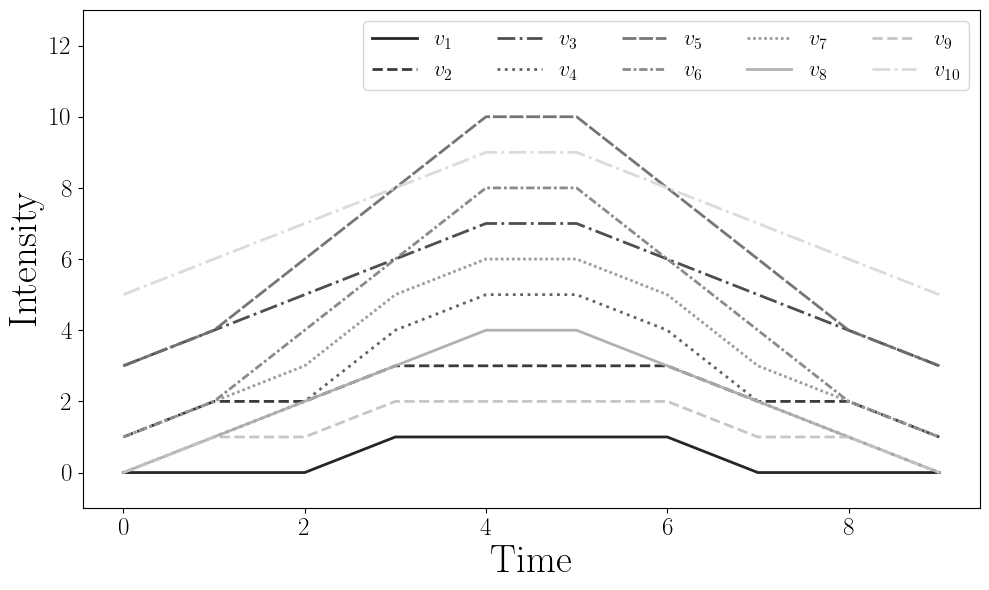

In [4]:
plt.figure(figsize=(10,6))

n = time_series.shape[0]
gray_levels = np.linspace(0.10, 0.85, n)
line_styles = ['-', '--', '-.', ':', (0, (5, 1)), (0, (3, 1, 1, 1)), (0, (1, 1)),
               '-', '--', '-.']

for i in range(n):
    plt.plot(time_series[i, :],
             linewidth=2,
             linestyle=line_styles[i],
             color=str(gray_levels[i]),
             alpha=0.95,
             label=fr'$v_{{{i+1}}}$')

plt.xlabel('Time', fontsize=28)
plt.ylabel('Intensity', fontsize=28)
plt.ylim(-1, 13)
plt.legend(loc="upper right", ncol=5, fontsize=16)
plt.tight_layout()
plt.show()


## Data Representation 2: MATRIX

The same time-series data can be visualized as a matrix where the rows indicate process variable indices and the columns correspond to time steps. 

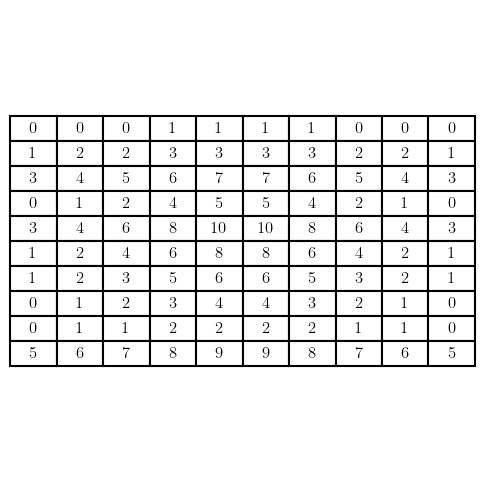

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.axis('off')

table = ax.table(
    cellText=time_series,
    loc='center',
    cellLoc='center',
    rowLoc='center',
)

for key, cell in table.get_celld().items():
    cell.set_edgecolor('black')
    cell.set_linewidth(1.5)
    cell.set_fontsize(12)

table.scale(1, 1.5)
plt.show()

## Data Representation 3: 2D MANIFOLD

The matrix can be represented as a heatmap, forming a 2D manifold whose pixel intensity reflects normalized process variables.

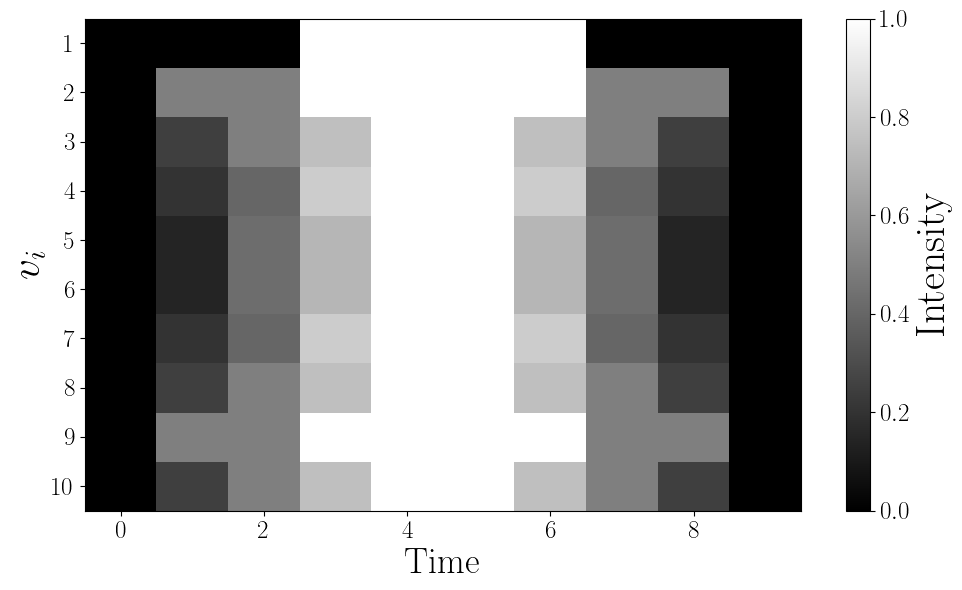

In [6]:
scalar = MinMaxScaler()
data_norm = scalar.fit_transform(time_series.T)
plt.figure(figsize=(10,6))
plt.imshow(data_norm.T, cmap='gray', aspect='auto')
plt.ylabel('$v_i$', fontsize=30)
plt.xlabel('Time', fontsize=26)
plt.yticks(np.arange(0, time_series.shape[0], 1), labels=np.arange(1, time_series.shape[0]+1, 1))  
cbar = plt.colorbar()
cbar.set_label("Intensity", fontsize=30)
plt.tight_layout()
plt.show()

## Data Representation 4: 3D MANIFOLD / FIELD

A 3D surface / field obtained by projecting intensities of the 2D manifold onto a third (vertical) axis, highlighting geometric structure (shape) in the data.

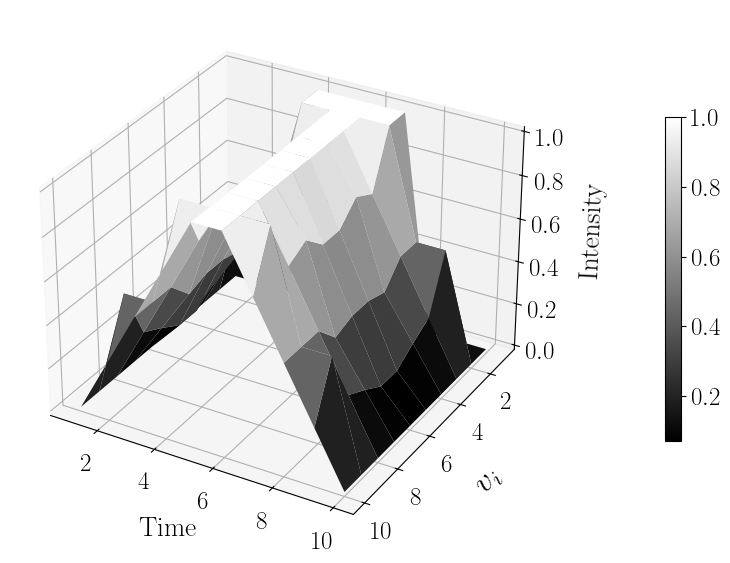

In [7]:
Z = np.asarray(data_norm.T, dtype=float)
H, W = Z.shape
X, Y = np.meshgrid(np.arange(W), np.arange(H))

fig = plt.figure(figsize=(15, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, cmap='gray', linewidth=0, antialiased=True)

ax.set_xlabel("Time", labelpad=12, fontsize=20)
ax.set_ylabel(r"$v_i$", labelpad=12, fontsize=24)
ax.set_zlabel("Intensity", labelpad=12, fontsize=20)

tick_labels = np.array([2, 4, 6, 8, 10])
ax.set_xticks(tick_labels - 1)
ax.set_xticklabels(tick_labels)
ax.set_yticks(tick_labels - 1)
ax.set_yticklabels(tick_labels)
ax.invert_yaxis()

fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1, label=' ')
plt.tight_layout()
plt.show()